<a href="https://colab.research.google.com/github/smartdxgen/Predicting-nephrotic-syndrome-outcomes-in-children-/blob/main/project_ns_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
!pip install "scikit-learn<1.0.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 23.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (pyproject.toml) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [ ]:
!pip install pycaret==2.3.10 scikit-learn==0.24.2

  Using cached scikit-learn-0.24.2.tar.gz (7.5 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (pyproject.toml) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [ ]:
file_path = '/content/drive/My Drive/project_NS/ns-10-4-1402.xlsx'

In [ ]:
df = pd.read_excel(file_path , sheet_name="Sheet2")

In [ ]:
df.head(10)

,Sex,Age,Congenital,Relaionship,PMH,Chol,tg,c4,c3,ANA,...,Wbc(blood),Rbc(blood),Hb(blood),Plt(blood),PR Urea,Wbc(Urea),Rbc(Urea),NS type,Biopsy,NS
0,Female,Less than 10 years,No,Yes,NaN,High,Border line,Normal,NaN,Neg,...,Medium,High,Medium,Medium,Pos,Pos,Pos,Resistant to treatment,NaN,Primary
1,Male,Less than 10 years,No,Yes,Pre Term,High,Border line,NaN,NaN,NaN,...,Medium,Low,Low,Medium,Pos,Pos,Pos,Frequent relaps,mpgn,Primary
2,Female,Less than 10 years,No,No,NaN,High,Pathologic,NaN,NaN,NaN,...,High,Medium,Medium,High,Pos,Pos,Pos,Frequent relaps,mpgn,Primary
3,Male,More than 10 years,No,No,NaN,High,Border line,NaN,NaN,NaN,...,High,NaN,High,High,Pos,NaN,NaN,Frequent relaps,mpgn,Primary
4,Male,More than 10 years,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Medium,High,High,Medium,Pos,Pos,Pos,Frequent relaps,mpgn,Primary
5,Female,Less than 10 years,No,No,Term,High,Pathologic,NaN,NaN,Neg,...,Medium,Low,Low,High,Pos,Pos,Pos,Frequent relaps,Rpgn,NaN
6,Female,Less than 10 years,No,NaN,Term,High,Pathologic,Normal,Normal,Neg,...,NaN,NaN,NaN,NaN,Pos,Pos,Pos,Frequent relaps,fsgs,Primary
7,Male,Less than 10 years,No,NaN,Term,NaN,NaN,NaN,NaN,NaN,...,High,High,High,Medium,NaN,NaN,NaN,Frequent relaps,NaN,Primary
8,Female,Less than 10 years,No,No,Term,High,Pathologic,NaN,NaN,NaN,...,High,Medium,Medium,High,Pos,Pos,Pos,Frequent relaps,NaN,Primary
9,Female,Less than 10 years,No,No,Pre Term,High,Pathologic,NaN,NaN,NaN,...,High,Medium,Medium,High,Pos,Pos,Pos,Frequent relaps,NaN,Primary


In [ ]:
df.columns

Index(['Sex', 'Age', 'Congenital', 'Relaionship', 'PMH', 'Chol', 'tg', 'c4',
       'c3', 'ANA', 'Alb', 'Wbc(blood)', 'Rbc(blood)', 'Hb(blood)',
       'Plt(blood)', 'PR Urea', 'Wbc(Urea)', 'Rbc(Urea)', 'NS type', 'Biopsy',
       'NS'],
      dtype='object')

سندرم نفرتیک یک وضعیت پزشکی است که با علامت‌های مختلفی در بیماران بروز می‌کند. هر یک از مفاهیمی که در جدول ذکر شده‌اند می‌توانند نقش مهمی در بررسی، تشخیص و مدیریت این بیماری داشته باشند. در ادامه، اهمیت هر یک از این مفاهیم در خصوص سندرم نفرتیک توضیح داده شده است:

1. **Sex** (جنسیت):
   - جنسیت می‌تواند بر روی شایع‌ترین عوامل زمینه‌ساز و پاسخ به درمان تأثیر داشته باشد.

2. **Age** (سن):
   - سندرم نفرتیک ممکن است در هر سنی رخ دهد، اما علل و پیامدها ممکن است در افراد مختلف با سنین مختلف متفاوت باشد.

3. **Congenital** (ارثی):
   - اطلاعات مربوط به عوامل ارثی می‌تواند به تشخیص بیماری‌های ژنتیکی و دیگر عوامل زمینه‌ساز کمک کند.

4. **Relationship** (رابطه):
   - اطلاعات خانواده و اخبار مرتبط با بیماری ممکن است در شناسایی الگوهای ارثی و تعیین بهتر درمان‌ها مؤثر باشد.

5. **PMH (Past Medical History)** (سابقهٔ پزشکی):
   - سابقهٔ پزشکی بیماران اطلاعات مفیدی در مورد بیماری‌های قبلی، عوامل خطر و پاسخ‌های درمانی فراهم می‌کند.

6. **Chol** (کلسترول):
   - بیماران مبتلا به سندرم نفرتیک معمولاً سطوح بالای کلسترول دارند که باید نظارت شوند.

7. **TG** (تری‌گلیسرید):
   - تری‌گلیسریدهای بالا نیز در بیماران مبتلا به سندرم نفرتیک شایع است.

8. **C4** و **C3**:
   - سطوح کمپلمان می‌تواند به تشخیص بیماری‌های خاص و افتراق بین انواع مختلف سندرم نفرتیک کمک کند.

9. **ANA**:
   - آنتی‌بادی‌های ضد هسته‌ای ممکن است برای شناسایی بیماری‌های خود ایمنی همراه با سندرم نفرتیک کاربردی باشند.

10. **Alb (آلبومین)**:
    - سطح آلبومین در خون به عنوان شاخص مهمی از عملکرد کلیه‌ها و شدت از دست دادن پروتئین محسوب می‌شود.

11. **WBC (White Blood Cells)** در خون:
    - تعداد گلبول‌های سفید در خون می‌تواند نشانه‌ای از عفونت یا التهاب باشد.

12. **RBC (Red Blood Cells)** در خون:
    - کاهش یا افزایش تعداد گلبول‌های قرمز می‌تواند نشانه‌ای از مشکلات کلیوی یا نظامیک باشد.

13. **Hb (Hemoglobin)**:
    - سطح هموگلوبین برای تشخیص کم‌خونی و دیگر اختلالات خونی مهم است.

14. **PLT (Platelets)** در خون:
    - تعداد پلاکت‌ها می‌تواند به ارزیابی خطر خونریزی و دیگر مشکلات مرتبط با خونریزی کمک کند.

15. **PR Urea**:
    - سطح اوره در خون به عنوان شاخصی از عملکرد کلیوی استفاده می‌شود.

16. **WBC در اوره**:
    - تعداد گلبول‌های سفید در ادرار نشانه‌ای از عفونت‌های ادراری یا التهاب کلیه‌ها باشد.

17. **RBC در اوره**:
    - وجود گلبول‌های قرمز در ادرار ممکن است نشانهٔ خونریزی یا آسیب کلیوی باشد
    

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Sex          243 non-null    object
 1   Age          242 non-null    object
 2   Congenital   243 non-null    object
 3   Relaionship  183 non-null    object
 4   PMH          184 non-null    object
 5   Chol         152 non-null    object
 6   tg           154 non-null    object
 7   c4           75 non-null     object
 8   c3           74 non-null     object
 9   ANA          49 non-null     object
 10  Alb          208 non-null    object
 11  Wbc(blood)   225 non-null    object
 12  Rbc(blood)   222 non-null    object
 13  Hb(blood)    227 non-null    object
 14  Plt(blood)   222 non-null    object
 15  PR Urea      223 non-null    object
 16  Wbc(Urea)    204 non-null    object
 17  Rbc(Urea)    210 non-null    object
 18  NS type      243 non-null    object
 19  Biopsy       159 non-null    

In [ ]:
df.describe()

,Sex,Age,Congenital,Relaionship,PMH,Chol,tg,c4,c3,ANA,...,Wbc(blood),Rbc(blood),Hb(blood),Plt(blood),PR Urea,Wbc(Urea),Rbc(Urea),NS type,Biopsy,NS
count,243,242,243,183,184,152,154,75,74,49,...,225,222,227,222,223,204,210,243,159,230
unique,2,4,2,2,3,3,3,3,3,2,...,3,3,3,3,2,2,1,4,6,2
top,Male,Less than 10 years,No,No,Term,High,Pathologic,Normal,Normal,Neg,...,High,Medium,Medium,Medium,Pos,Pos,Pos,Resistant to treatment,fsgs,Primary
freq,145,166,200,98,154,124,59,61,55,48,...,126,145,123,111,213,203,210,144,62,167


In [ ]:
df.isnull().sum()

,0
Sex,0
Age,1
Congenital,0
Relaionship,60
PMH,59
Chol,91
tg,89
c4,168
c3,169
ANA,194


## **Edit columns value**

In [ ]:
df['Relaionship'].fillna('No', inplace=True)

<ipython-input-12-a7d1b2b5c1a6>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Relaionship'].fillna('No', inplace=True)


In [ ]:
df['PMH'].fillna('Term', inplace=True)

<ipython-input-13-8623f08173be>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['PMH'].fillna('Term', inplace=True)


In [ ]:
df['Biopsy'].fillna('Null' , inplace=True)

<ipython-input-14-b20be60cae9b>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Biopsy'].fillna('Null' , inplace=True)


In [ ]:
df['c3'].fillna('Null', inplace=True)
df['c4'].fillna('Null', inplace=True)
df['ANA'].fillna('Null' , inplace=True)
df['Alb'].fillna('Null' , inplace=True)

<ipython-input-15-fff986b0895b>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['c3'].fillna('Null', inplace=True)
<ipython-input-15-fff986b0895b>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.metho

In [ ]:
df['Chol'].fillna('Normal', inplace=True)
df['tg'].fillna('Normal', inplace=True)

<ipython-input-16-8f98e7113894>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Chol'].fillna('Normal', inplace=True)
<ipython-input-16-8f98e7113894>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.m

In [ ]:
df['Wbc(blood)'].fillna('Null', inplace=True)
df['Rbc(blood)'].fillna('Null', inplace=True)
df['Hb(blood)'].fillna('Null', inplace=True)
df['Plt(blood)'].fillna('Null', inplace=True)

<ipython-input-17-8276b3e971a3>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Wbc(blood)'].fillna('Null', inplace=True)
<ipython-input-17-8276b3e971a3>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using '

In [ ]:
df['PR Urea'].fillna('Null', inplace=True)
df['Wbc(Urea)'].fillna('Null', inplace=True)
df['Rbc(Urea)'].fillna('Null', inplace=True)

<ipython-input-18-7a4bc7e5abf2>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['PR Urea'].fillna('Null', inplace=True)
<ipython-input-18-7a4bc7e5abf2>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.

In [ ]:
df.isnull().sum()

,0
Sex,0
Age,1
Congenital,0
Relaionship,0
PMH,0
Chol,0
tg,0
c4,0
c3,0
ANA,0


In [ ]:
updated_file_path = '/content/drive/My Drive/project_NS/update_ns.xlsx'
df.to_excel(updated_file_path, index=False)

## **Input**

<ipython-input-21-7de76004f62a>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Sex', data=df, palette={'Male': '#00ffff', 'Female': '#f90063'})


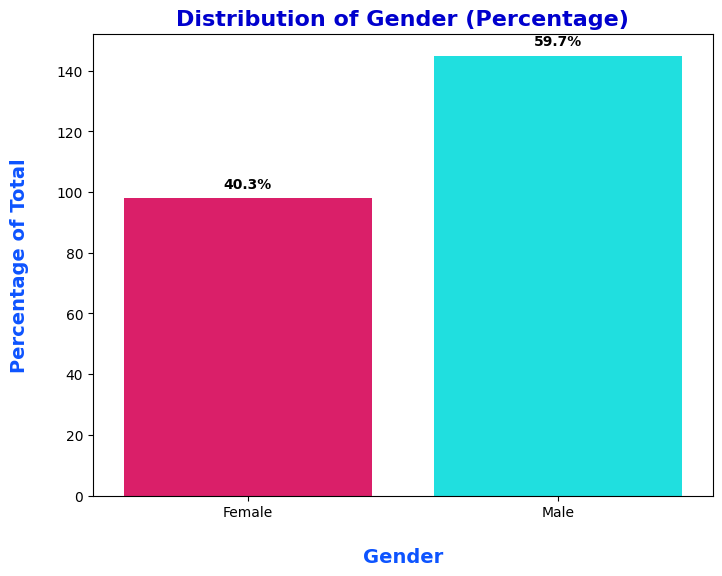

In [ ]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='Sex', data=df, palette={'Male': '#00ffff', 'Female': '#f90063'})

total = float(len(df))

for p in ax.patches:
    height = p.get_height()
    percentage = (height / total) * 100
    ax.annotate(f'{percentage:.1f}%', (p.get_x() + p.get_width() / 2., height), ha='center', va='center', xytext=(0, 10), textcoords='offset points', color='black', weight='bold')

plt.xlabel('Gender', weight="bold", color="#0d54ff", fontsize=14, labelpad=20)
plt.ylabel('Percentage of Total', weight="bold", color="#0d54ff", fontsize=14, labelpad=20)
plt.title('Distribution of Gender (Percentage)', weight="bold", color="#0000cd", fontsize=16)

plt.show()

In [ ]:
df['Age'].value_counts()

,count
Age,
Less than 10 years,166
less than 1 year,37
More than 10 years,34
< 1 month,5


<ipython-input-23-45f757b07f39>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Age', data=df_sorted, palette={'Less than 10 years': '#00ffff', 'less than 1 year': '#ff930f', 'More than 10 years': '#f90063', '< 1 month': '#bf0fff'})


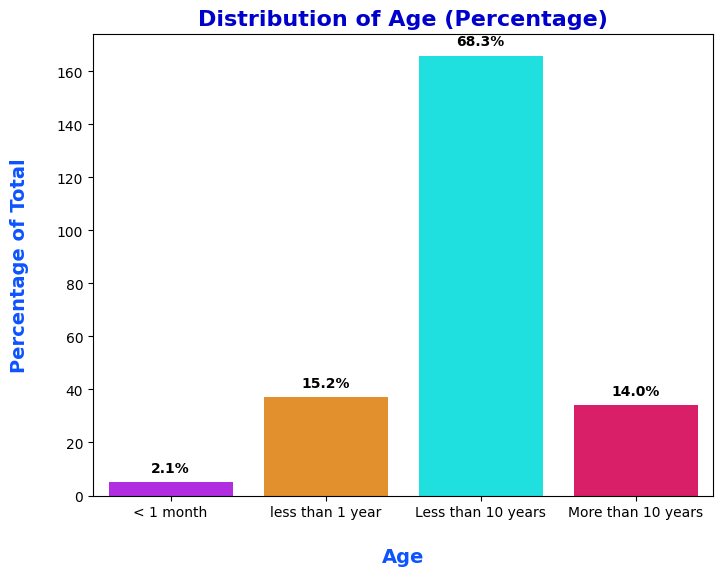

In [ ]:
order = ['< 1 month', 'less than 1 year', 'Less than 10 years', 'More than 10 years']
df['Age'] = pd.Categorical(df['Age'], categories=order, ordered=True)

df_sorted = df.sort_values(by='Age')

plt.figure(figsize=(8, 6))
ax = sns.countplot(x='Age', data=df_sorted, palette={'Less than 10 years': '#00ffff', 'less than 1 year': '#ff930f', 'More than 10 years': '#f90063', '< 1 month': '#bf0fff'})

total = float(len(df_sorted))

for p in ax.patches:
    height = p.get_height()
    percentage = (height / total) * 100
    ax.annotate(f'{percentage:.1f}%', (p.get_x() + p.get_width() / 2., height), ha='center', va='center', xytext=(0, 10), textcoords='offset points', color='black', weight='bold')

plt.xlabel('Age', weight="bold", color="#0d54ff", fontsize=14, labelpad=20)
plt.ylabel('Percentage of Total', weight="bold", color="#0d54ff", fontsize=14, labelpad=20)
plt.title('Distribution of Age (Percentage)', weight="bold", color="#0000cd", fontsize=16)

plt.show()

In [ ]:
df['Congenital'].value_counts()

,count
Congenital,
No,200
Yes,43


<ipython-input-25-c220fc350cae>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Congenital', data=df, palette={'No': '#f90063', 'Yes': '#00ffff'})


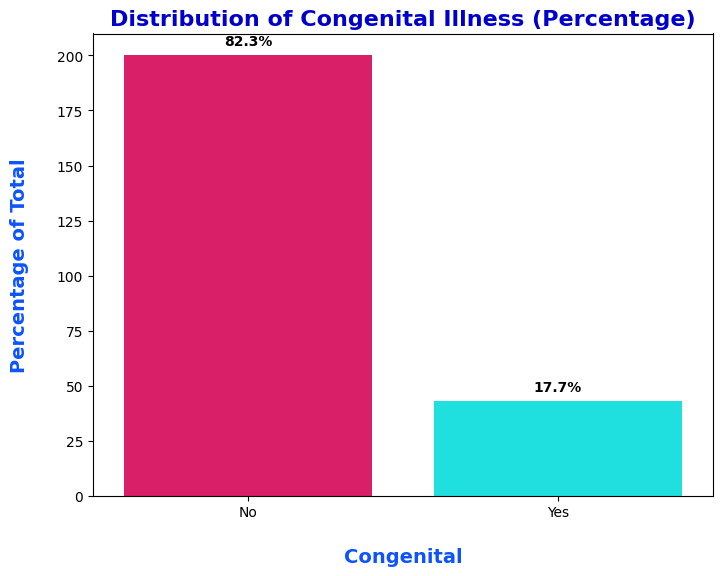

In [ ]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='Congenital', data=df, palette={'No': '#f90063', 'Yes': '#00ffff'})

total = float(len(df))

for p in ax.patches:
    height = p.get_height()
    percentage = (height / total) * 100
    ax.annotate(f'{percentage:.1f}%', (p.get_x() + p.get_width() / 2., height), ha='center', va='center', xytext=(0, 10), textcoords='offset points', color='black', weight='bold')

plt.xlabel('Congenital', weight="bold", color="#0d54ff", fontsize=14, labelpad=20)
plt.ylabel('Percentage of Total', weight="bold", color="#0d54ff", fontsize=14, labelpad=20)
plt.title('Distribution of Congenital Illness (Percentage)', weight="bold", color="#0000cd", fontsize=16)

plt.show()

In [ ]:
df['Relaionship'].value_counts()

,count
Relaionship,
No,158
Yes,85


<ipython-input-27-3b1c59bd4a04>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Relaionship', data=df, palette={'No': '#f90063', 'Yes': '#00ffff'})


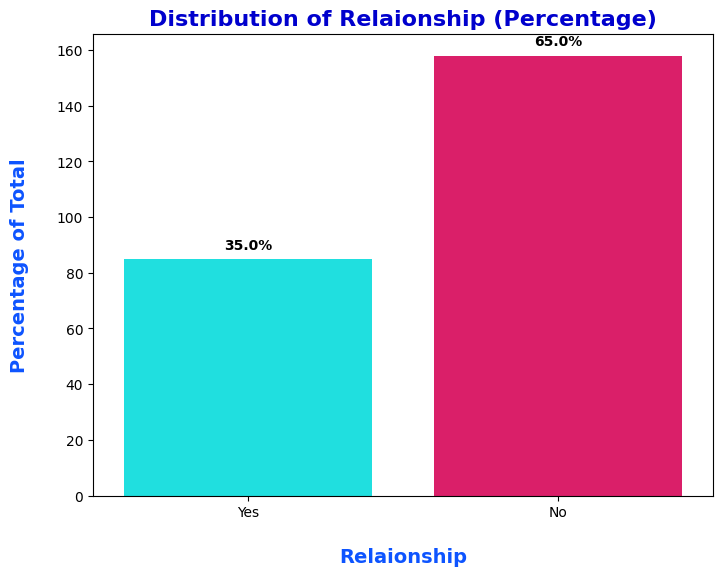

In [ ]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='Relaionship', data=df, palette={'No': '#f90063', 'Yes': '#00ffff'})

total = float(len(df))

for p in ax.patches:
    height = p.get_height()
    percentage = (height / total) * 100
    ax.annotate(f'{percentage:.1f}%', (p.get_x() + p.get_width() / 2., height), ha='center', va='center', xytext=(0, 10), textcoords='offset points', color='black', weight='bold')

plt.xlabel('Relaionship', weight="bold", color="#0d54ff", fontsize=14, labelpad=20)
plt.ylabel('Percentage of Total', weight="bold", color="#0d54ff", fontsize=14, labelpad=20)
plt.title('Distribution of Relaionship (Percentage)', weight="bold", color="#0000cd", fontsize=16)

plt.show()

In [ ]:
df['PMH'].value_counts()

,count
PMH,
Term,213
Pre Term,29
Post Term,1


<ipython-input-29-ed43b70aa7cb>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='PMH', data=df, palette={'Term': '#00ffff', 'Pre Term': '#f90063' , 'Post Term' : '#ff930f'})


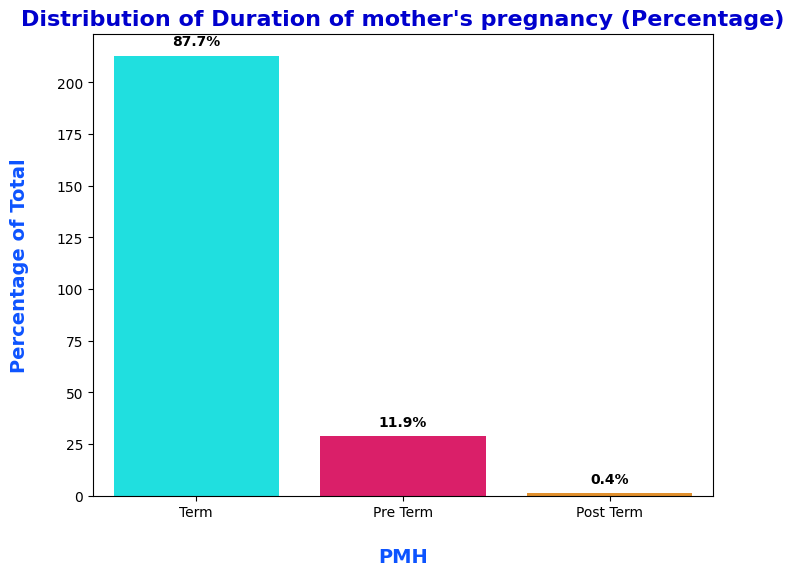

In [ ]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='PMH', data=df, palette={'Term': '#00ffff', 'Pre Term': '#f90063' , 'Post Term' : '#ff930f'})

total = float(len(df))

for p in ax.patches:
    height = p.get_height()
    percentage = (height / total) * 100
    ax.annotate(f'{percentage:.1f}%', (p.get_x() + p.get_width() / 2., height), ha='center', va='center', xytext=(0, 10), textcoords='offset points', color='black', weight='bold')

plt.xlabel('PMH', weight="bold", color="#0d54ff", fontsize=14, labelpad=20)
plt.ylabel('Percentage of Total', weight="bold", color="#0d54ff", fontsize=14, labelpad=20)
plt.title("Distribution of Duration of mother's pregnancy (Percentage)", weight="bold", color="#0000cd", fontsize=16)

plt.show()

In [ ]:
df['Chol'].value_counts()

,count
Chol,
High,124
Normal,110
Border line,9


<ipython-input-31-5c4b4207980a>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Chol', data=df, palette={'High': '#f90063', 'Normal': '#00ffff' , 'Border line' : '#ff930f'})


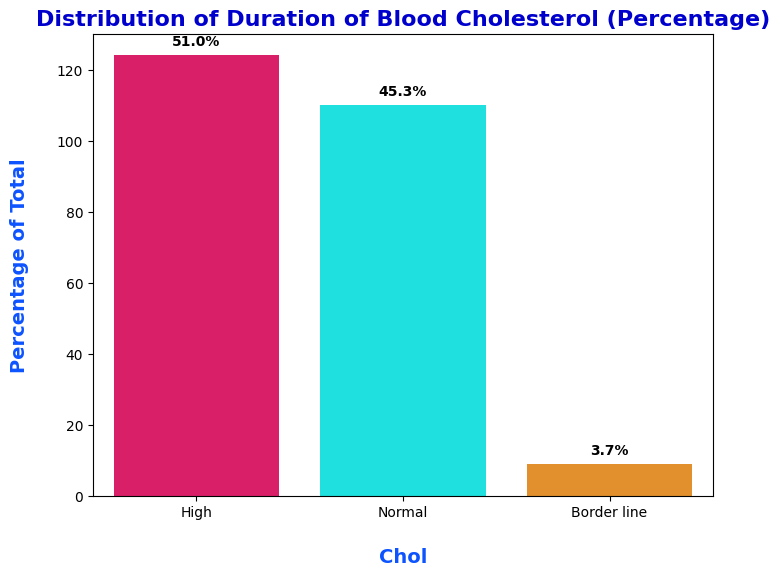

In [ ]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='Chol', data=df, palette={'High': '#f90063', 'Normal': '#00ffff' , 'Border line' : '#ff930f'})

total = float(len(df))

for p in ax.patches:
    height = p.get_height()
    percentage = (height / total) * 100
    ax.annotate(f'{percentage:.1f}%', (p.get_x() + p.get_width() / 2., height), ha='center', va='center', xytext=(0, 10), textcoords='offset points', color='black', weight='bold')

plt.xlabel('Chol', weight="bold", color="#0d54ff", fontsize=14, labelpad=20)
plt.ylabel('Percentage of Total', weight="bold", color="#0d54ff", fontsize=14, labelpad=20)
plt.title("Distribution of Duration of Blood Cholesterol (Percentage)", weight="bold", color="#0000cd", fontsize=16)

plt.show()

In [ ]:
df['tg'].value_counts()

,count
tg,
Normal,131
Pathologic,59
Border line,53


<ipython-input-33-ebe2fe0e36ba>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='tg', data=df, palette={'Pathologic': '#f90063', 'Normal': '#00ffff' , 'Border line' : '#ff930f'})


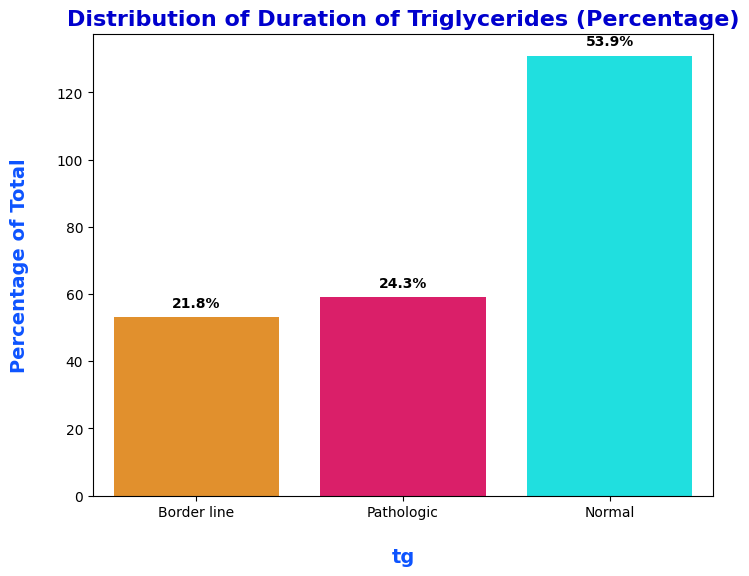

In [ ]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='tg', data=df, palette={'Pathologic': '#f90063', 'Normal': '#00ffff' , 'Border line' : '#ff930f'})

total = float(len(df))

for p in ax.patches:
    height = p.get_height()
    percentage = (height / total) * 100
    ax.annotate(f'{percentage:.1f}%', (p.get_x() + p.get_width() / 2., height), ha='center', va='center', xytext=(0, 10), textcoords='offset points', color='black', weight='bold')

plt.xlabel('tg', weight="bold", color="#0d54ff", fontsize=14, labelpad=20)
plt.ylabel('Percentage of Total', weight="bold", color="#0d54ff", fontsize=14, labelpad=20)
plt.title("Distribution of Duration of Triglycerides (Percentage)", weight="bold", color="#0000cd", fontsize=16)

plt.show()

In [ ]:
df['c4'].value_counts()

,count
c4,
Null,168
Normal,61
Low,11
High,3


<ipython-input-35-ad532f2f7fa5>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='c4', data=df, palette={'High': '#f90063', 'Normal': '#00ffff' , 'Low' : '#ff930f' , 'Null' : 'red'})


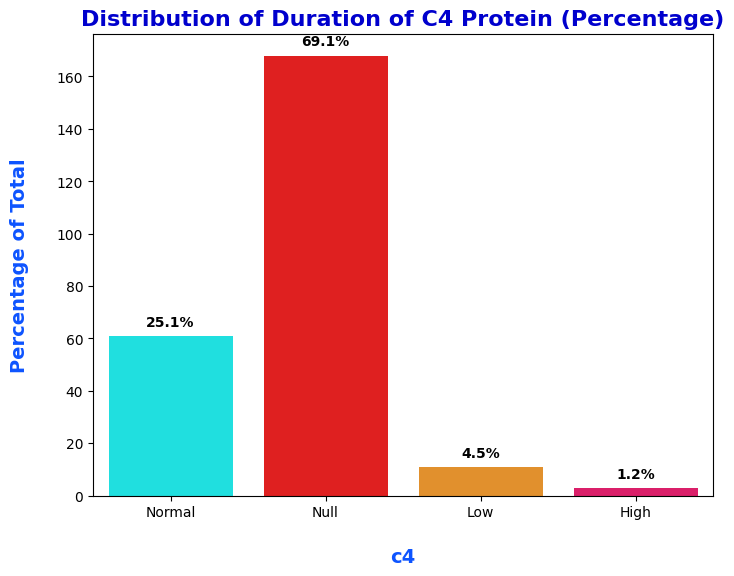

In [ ]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='c4', data=df, palette={'High': '#f90063', 'Normal': '#00ffff' , 'Low' : '#ff930f' , 'Null' : 'red'})

total = float(len(df))

for p in ax.patches:
    height = p.get_height()
    percentage = (height / total) * 100
    ax.annotate(f'{percentage:.1f}%', (p.get_x() + p.get_width() / 2., height), ha='center', va='center', xytext=(0, 10), textcoords='offset points', color='black', weight='bold')

plt.xlabel('c4', weight="bold", color="#0d54ff", fontsize=14, labelpad=20)
plt.ylabel('Percentage of Total', weight="bold", color="#0d54ff", fontsize=14, labelpad=20)
plt.title("Distribution of Duration of C4 Protein (Percentage)", weight="bold", color="#0000cd", fontsize=16)

plt.show()

In [ ]:
df['c3'].value_counts()

,count
c3,
Null,169
Normal,55
High,14
Low,5


<ipython-input-37-28e2fbc5cfcb>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='c3', data=df, palette={'High': '#f90063', 'Normal': '#00ffff' , 'Low' : '#ff930f' , 'Null' : 'red'})


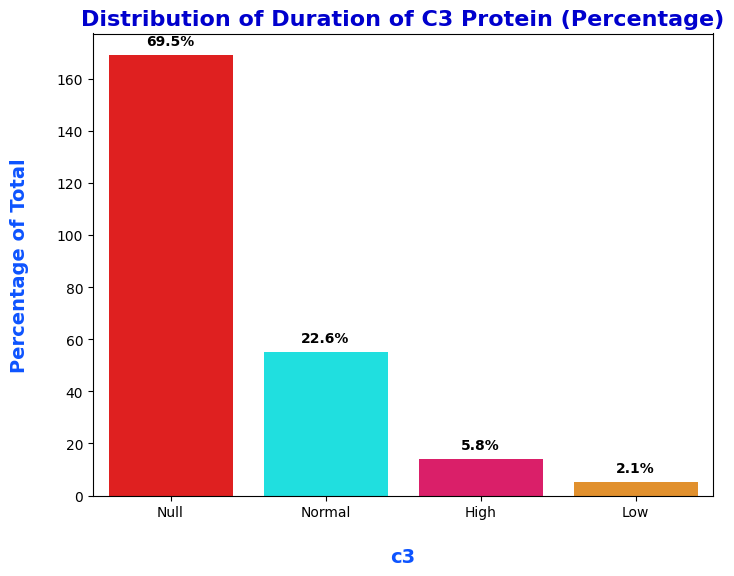

In [ ]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='c3', data=df, palette={'High': '#f90063', 'Normal': '#00ffff' , 'Low' : '#ff930f' , 'Null' : 'red'})

total = float(len(df))

for p in ax.patches:
    height = p.get_height()
    percentage = (height / total) * 100
    ax.annotate(f'{percentage:.1f}%', (p.get_x() + p.get_width() / 2., height), ha='center', va='center', xytext=(0, 10), textcoords='offset points', color='black', weight='bold')

plt.xlabel('c3', weight="bold", color="#0d54ff", fontsize=14, labelpad=20)
plt.ylabel('Percentage of Total', weight="bold", color="#0d54ff", fontsize=14, labelpad=20)
plt.title("Distribution of Duration of C3 Protein (Percentage)", weight="bold", color="#0000cd", fontsize=16)

plt.show()

In [ ]:
df['ANA'].value_counts()

,count
ANA,
Null,194
Neg,48
Pos,1


<ipython-input-39-81b1313c7034>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='ANA', data=df, palette={'Neg': '#f90063', 'Pos': '#00ffff' , 'Null' : 'red'})


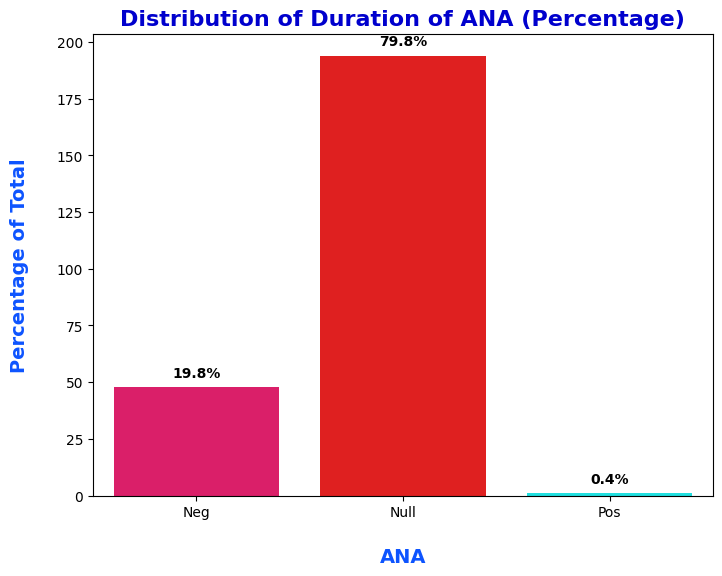

In [ ]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='ANA', data=df, palette={'Neg': '#f90063', 'Pos': '#00ffff' , 'Null' : 'red'})

total = float(len(df))

for p in ax.patches:
    height = p.get_height()
    percentage = (height / total) * 100
    ax.annotate(f'{percentage:.1f}%', (p.get_x() + p.get_width() / 2., height), ha='center', va='center', xytext=(0, 10), textcoords='offset points', color='black', weight='bold')

plt.xlabel('ANA', weight="bold", color="#0d54ff", fontsize=14, labelpad=20)
plt.ylabel('Percentage of Total', weight="bold", color="#0d54ff", fontsize=14, labelpad=20)
plt.title("Distribution of Duration of ANA (Percentage)", weight="bold", color="#0000cd", fontsize=16)

plt.show()

In [ ]:
df['Alb'].value_counts()

,count
Alb,
Low,194
Null,35
Medium,14


<ipython-input-41-32c1ba325bb9>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Alb', data=df, palette={'Low': '#f90063', 'Medium': '#00ffff' , 'Null' : 'red'})


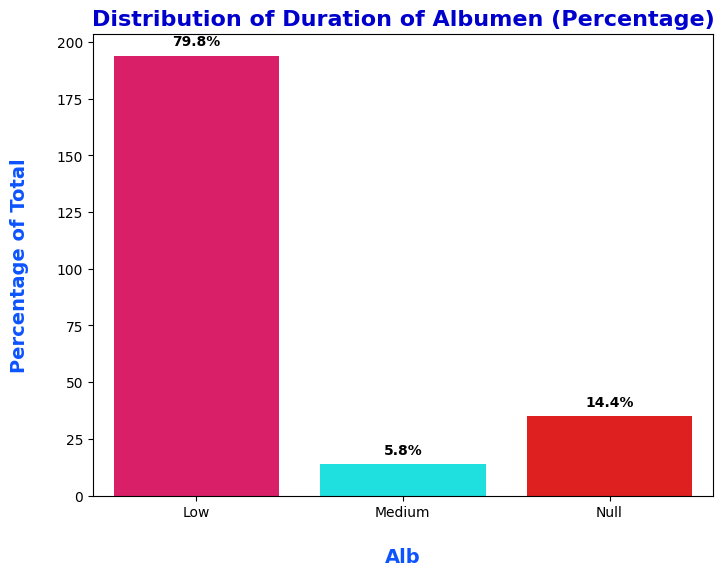

In [ ]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='Alb', data=df, palette={'Low': '#f90063', 'Medium': '#00ffff' , 'Null' : 'red'})

total = float(len(df))

for p in ax.patches:
    height = p.get_height()
    percentage = (height / total) * 100
    ax.annotate(f'{percentage:.1f}%', (p.get_x() + p.get_width() / 2., height), ha='center', va='center', xytext=(0, 10), textcoords='offset points', color='black', weight='bold')

plt.xlabel('Alb', weight="bold", color="#0d54ff", fontsize=14, labelpad=20)
plt.ylabel('Percentage of Total', weight="bold", color="#0d54ff", fontsize=14, labelpad=20)
plt.title("Distribution of Duration of Albumen (Percentage)", weight="bold", color="#0000cd", fontsize=16)

plt.show()

In [ ]:
df['Wbc(blood)'].value_counts()

,count
Wbc(blood),
High,126
Medium,94
Null,18
Low,5


<ipython-input-43-e5e94c7bb110>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Wbc(blood)', data=df, palette={'High': '#f90063', 'Medium': '#00ffff' , 'Low' : '#ff930f'})


ValueError: The palette dictionary is missing keys: {'Null'}

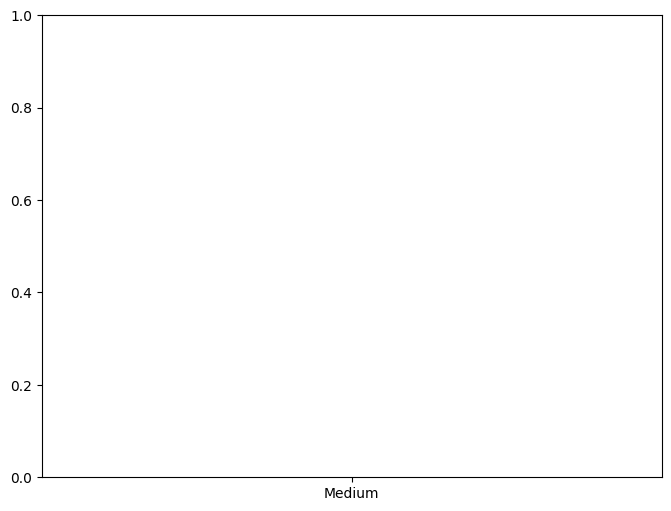

In [ ]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='Wbc(blood)', data=df, palette={'High': '#f90063', 'Medium': '#00ffff' , 'Low' : '#ff930f'})

total = float(len(df))

for p in ax.patches:
    height = p.get_height()
    percentage = (height / total) * 100
    ax.annotate(f'{percentage:.1f}%', (p.get_x() + p.get_width() / 2., height), ha='center', va='center', xytext=(0, 10), textcoords='offset points', color='black', weight='bold')

plt.xlabel('Wbc(blood)', weight="bold", color="#0d54ff", fontsize=14, labelpad=20)
plt.ylabel('Percentage of Total', weight="bold", color="#0d54ff", fontsize=14, labelpad=20)
plt.title("Distribution of Duration of Wbc(blood) (Percentage)", weight="bold", color="#0000cd", fontsize=16)

plt.show()

In [ ]:
df['Rbc(blood)'].value_counts()

In [ ]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='Rbc(blood)', data=df, palette={'High': '#f90063', 'Medium': '#00ffff' , 'Low' : '#ff930f'})

total = float(len(df))

for p in ax.patches:
    height = p.get_height()
    percentage = (height / total) * 100
    ax.annotate(f'{percentage:.1f}%', (p.get_x() + p.get_width() / 2., height), ha='center', va='center', xytext=(0, 10), textcoords='offset points', color='black', weight='bold')

plt.xlabel('Rbc(blood)', weight="bold", color="#0d54ff", fontsize=14, labelpad=20)
plt.ylabel('Percentage of Total', weight="bold", color="#0d54ff", fontsize=14, labelpad=20)
plt.title("Distribution of Duration of Rbc(blood) (Percentage)", weight="bold", color="#0000cd", fontsize=16)

plt.show()

In [ ]:
df['Hb(blood)'].value_counts()

In [ ]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='Hb(blood)', data=df, palette={'High': '#f90063', 'Medium': '#00ffff' , 'Low' : '#ff930f'})

total = float(len(df))

for p in ax.patches:
    height = p.get_height()
    percentage = (height / total) * 100
    ax.annotate(f'{percentage:.1f}%', (p.get_x() + p.get_width() / 2., height), ha='center', va='center', xytext=(0, 10), textcoords='offset points', color='black', weight='bold')

plt.xlabel('Hb(blood)', weight="bold", color="#0d54ff", fontsize=14, labelpad=20)
plt.ylabel('Percentage of Total', weight="bold", color="#0d54ff", fontsize=14, labelpad=20)
plt.title("Distribution of Duration of Hb(blood) (Percentage)", weight="bold", color="#0000cd", fontsize=16)

plt.show()

In [ ]:
df['Plt(blood)'].value_counts()

In [ ]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='Plt(blood)', data=df, palette={'High': '#f90063', 'Medium': '#00ffff' , 'Low' : '#ff930f'})

total = float(len(df))

for p in ax.patches:
    height = p.get_height()
    percentage = (height / total) * 100
    ax.annotate(f'{percentage:.1f}%', (p.get_x() + p.get_width() / 2., height), ha='center', va='center', xytext=(0, 10), textcoords='offset points', color='black', weight='bold')

plt.xlabel('Plt(blood)', weight="bold", color="#0d54ff", fontsize=14, labelpad=20)
plt.ylabel('Percentage of Total', weight="bold", color="#0d54ff", fontsize=14, labelpad=20)
plt.title("Distribution of Duration of Plt(blood) (Percentage)", weight="bold", color="#0000cd", fontsize=16)

plt.show()

In [ ]:
df['PR Urea'].value_counts()

In [ ]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='PR Urea', data=df, palette={'Neg': '#f90063', 'Pos': '#00ffff'})

total = float(len(df))

for p in ax.patches:
    height = p.get_height()
    percentage = (height / total) * 100
    ax.annotate(f'{percentage:.1f}%', (p.get_x() + p.get_width() / 2., height), ha='center', va='center', xytext=(0, 10), textcoords='offset points', color='black', weight='bold')

plt.xlabel('PR Urea', weight="bold", color="#0d54ff", fontsize=14, labelpad=20)
plt.ylabel('Percentage of Total', weight="bold", color="#0d54ff", fontsize=14, labelpad=20)
plt.title("Distribution of Duration of PR Urea (Percentage)", weight="bold", color="#0000cd", fontsize=16)

plt.show()

In [ ]:
df['Wbc(Urea)'].value_counts()

In [ ]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='Wbc(Urea)', data=df, palette={'Neg': '#f90063', 'Pos': '#00ffff'})

total = float(len(df))

for p in ax.patches:
    height = p.get_height()
    percentage = (height / total) * 100
    ax.annotate(f'{percentage:.1f}%', (p.get_x() + p.get_width() / 2., height), ha='center', va='center', xytext=(0, 10), textcoords='offset points', color='black', weight='bold')

plt.xlabel('Wbc(Urea)', weight="bold", color="#0d54ff", fontsize=14, labelpad=20)
plt.ylabel('Percentage of Total', weight="bold", color="#0d54ff", fontsize=14, labelpad=20)
plt.title("Distribution of Duration of Wbc(Urea) (Percentage)", weight="bold", color="#0000cd", fontsize=16)

plt.show()

In [ ]:
df['Rbc(Urea)'].value_counts()

In [ ]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='Rbc(Urea)', data=df, palette={'Pos': '#00ffff'})

total = float(len(df))

for p in ax.patches:
    height = p.get_height()
    percentage = (height / total) * 100
    ax.annotate(f'{percentage:.1f}%', (p.get_x() + p.get_width() / 2., height), ha='center', va='center', xytext=(0, 10), textcoords='offset points', color='black', weight='bold')

plt.xlabel('Rbc(Urea)', weight="bold", color="#0d54ff", fontsize=14, labelpad=20)
plt.ylabel('Percentage of Total', weight="bold", color="#0d54ff", fontsize=14, labelpad=20)
plt.title("Distribution of Duration of Rbc(Urea) (Percentage)", weight="bold", color="#0000cd", fontsize=16)

plt.show()

## **Output**

In [ ]:
df.info()

In [ ]:
df['NS type'].value_counts()

In [ ]:
ns_type_counts = df['NS type'].value_counts()
plt.figure(figsize=(8, 6))
plt.pie(ns_type_counts, labels=ns_type_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of NS type', weight="bold", color="#C71585", fontsize=16)
plt.show()

In [ ]:
df['Biopsy'].value_counts()

In [ ]:
ns_type_counts = df['Biopsy'].value_counts()
plt.figure(figsize=(8, 6))
plt.pie(ns_type_counts, labels=ns_type_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Biopsy', weight="bold", color="#C71585", fontsize=16)
plt.show()

In [ ]:
df['NS'].value_counts()

In [ ]:
ns_counts = df['NS'].value_counts()
plt.figure(figsize=(8, 6))
plt.pie(ns_counts, labels=ns_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of NS', weight="bold", color="#C71585", fontsize=16)
plt.show()

## **Correlation**

### **Correlation of inputs with output**

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
colors = [ '#f90063', '#00ffff', '#bf0fff', '#ff930f']
total = 243

In [ ]:
sex_ns_type_distribution = df.groupby(['NS type', 'Sex']).size().unstack()
print(sex_ns_type_distribution)

In [ ]:
sex_ns_type_distribution_percent = (sex_ns_type_distribution / total) * 100
print(sex_ns_type_distribution_percent)

In [ ]:
sex_ns_type_distribution.plot(kind='bar', stacked=True,color = colors ,figsize=(8, 6))

plt.title('Distribution of Sex by NS Type')
plt.xlabel('NS Type')
plt.ylabel('Count')

plt.legend(title='Sex')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
age_ns_type_distribution = df.groupby(['NS type', 'Age']).size().unstack()
print(age_ns_type_distribution)

In [ ]:
age_ns_type_distribution_percent = (age_ns_type_distribution / total) * 100
print(age_ns_type_distribution_percent)

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(age_ns_type_distribution_percentage, annot=True, fmt='.1f', cmap='RdPu', cbar_kws={'label': 'Percentage (%)'})

plt.title('Heatmap of Age Distribution by NS Type')
plt.xlabel('Age')
plt.ylabel('NS Type')
plt.show()

In [ ]:
age_ns_type_distribution.plot(kind='bar', stacked=True, color = colors ,figsize=(8, 6))

plt.title('Distribution of Age by NS Type')
plt.xlabel('NS Type')
plt.ylabel('Count')

plt.legend(title='Age')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
age_ns_type_distribution.plot(kind='bar', stacked=True, color = colors ,figsize=(8, 6))

plt.title('Distribution of Age by NS Type')
plt.xlabel('NS Type')
plt.ylabel('Count')

plt.legend(title='Age')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
congenital_ns_type_distribution = df.groupby(['NS type', 'Congenital']).size().unstack()
print(congenital_ns_type_distribution)

In [ ]:
congenital_ns_type_distribution_percent = (congenital_ns_type_distribution / total) * 100
print(congenital_ns_type_distribution_percent)

In [ ]:
congenital_ns_type_distribution.plot(kind='bar', stacked=True, color = colors ,figsize=(8, 6))

plt.title('Distribution of Congenital by NS Type')
plt.xlabel('NS Type')
plt.ylabel('Count')

plt.legend(title='Congenital')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
relaionship_ns_type_distribution = df.groupby(['NS type', 'Relaionship']).size().unstack()
print(relaionship_ns_type_distribution)

In [ ]:
relaionship_ns_type_distribution_percent = (relaionship_ns_type_distribution / total) * 100
print(relaionship_ns_type_distribution_percent)

In [ ]:
relaionship_ns_type_distribution.plot(kind='bar', stacked=True, color = colors ,figsize=(8, 6))

plt.title('Distribution of Relaionship by NS Type')
plt.xlabel('NS Type')
plt.ylabel('Count')

plt.legend(title='Relaionship')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
pmh_ns_type_distribution = df.groupby(['NS type', 'PMH']).size().unstack()
print(pmh_ns_type_distribution)

In [ ]:
pmh_ns_type_distribution_percent = (pmh_ns_type_distribution / total) * 100
print(pmh_ns_type_distribution_percent)

In [ ]:
pmh_ns_type_distribution.plot(kind='bar', stacked=True, color = colors ,figsize=(8, 6))

plt.title('Distribution of PMH by NS Type')
plt.xlabel('NS Type')
plt.ylabel('Count')

plt.legend(title='PMH')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
chol_ns_type_distribution = df.groupby(['NS type', 'Chol']).size().unstack()
print(chol_ns_type_distribution)

In [ ]:
chol_ns_type_distribution_percent = (chol_ns_type_distribution / total) * 100
print(chol_ns_type_distribution_percent)

In [ ]:
chol_ns_type_distribution.plot(kind='bar', stacked=True, color = colors ,figsize=(8, 6))

plt.title('Distribution of Chol by NS Type')
plt.xlabel('NS Type')
plt.ylabel('Count')

plt.legend(title='Chol')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
tg_ns_type_distribution = df.groupby(['NS type', 'tg']).size().unstack()
print(tg_ns_type_distribution)

In [ ]:
tg_ns_type_distribution_percent = (tg_ns_type_distribution / total) * 100
print(tg_ns_type_distribution_percent)

In [ ]:
tg_ns_type_distribution.plot(kind='bar', stacked=True, color = colors ,figsize=(8, 6))

plt.title('Distribution of Tg by NS Type')
plt.xlabel('NS Type')
plt.ylabel('Count')

plt.legend(title='Tg')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
c4_ns_type_distribution = df.groupby(['NS type', 'c4']).size().unstack()
print(c4_ns_type_distribution)

In [ ]:
c4_ns_type_distribution_percent = (c4_ns_type_distribution / total) * 100
print(c4_ns_type_distribution_percent)

In [ ]:
c4_ns_distribution.plot(kind='bar', stacked=True, color = colors ,figsize=(8, 6))

plt.title('Distribution of c4 by NS Type')
plt.xlabel('NS Type')
plt.ylabel('Count')

plt.legend(title='c4')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
c3_ns_type_distribution = df.groupby(['NS type', 'c3']).size().unstack()
print(c3_ns_type_distribution)

In [ ]:
c3_ns_type_distribution_percent = (c3_ns_type_distribution / total) * 100
print(c3_ns_type_distribution_percent)

In [ ]:
c3_ns_type_distribution.plot(kind='bar', stacked=True, color = colors ,figsize=(8, 6))

plt.title('Distribution of c3 by NS Type')
plt.xlabel('NS Type')
plt.ylabel('Count')

plt.legend(title='c3')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
ana_ns_type_distribution = df.groupby(['NS type', 'ANA']).size().unstack()
print(ana_ns_type_distribution)

In [ ]:
ana_ns_type_distribution_percent = (ana_ns_type_distribution / total) * 100
print(ana_ns_type_distribution_percent)

In [ ]:
ana_ns_type_distribution.plot(kind='bar', stacked=True, color = {'Neg': '#f90063', 'Pos': '#00ffff' , 'Null' : 'red'} ,figsize=(8, 6))

plt.title('Distribution of ANA by NS Type')
plt.xlabel('NS Type')
plt.ylabel('Count')

plt.legend(title='ANA')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
alb_ns_type_distribution = df.groupby(['NS type', 'Alb']).size().unstack()
print(alb_ns_type_distribution)

In [ ]:
alb_ns_type_distribution_percent = (alb_ns_type_distribution / total) * 100
print(alb_ns_type_distribution_percent)

In [ ]:
alb_ns_type_distribution.plot(kind='bar', stacked=True, color = colors ,figsize=(8, 6))

plt.title('Distribution of Alb by NS Type')
plt.xlabel('NS Type')
plt.ylabel('Count')

plt.legend(title='Alb')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
wbc_ns_type_distribution = df.groupby(['NS type', 'Wbc(blood)']).size().unstack()
print(wbc_ns_type_distribution)

In [ ]:
wbc_ns_type_distribution_percent = (wbc_ns_type_distribution / total) * 100
print(wbc_ns_type_distribution_percent)

In [ ]:
wbc_ns_type_distribution.plot(kind='bar', stacked=True, color = colors ,figsize=(8, 6))

plt.title('Distribution of WBC by NS Type')
plt.xlabel('NS Type')
plt.ylabel('Count')

plt.legend(title='WBC')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
rbc_ns_type_distribution = df.groupby(['NS type', 'Rbc(blood)']).size().unstack()
print(rbc_ns_type_distribution)

In [ ]:
rbc_ns_type_distribution_percent = (rbc_ns_type_distribution / total) * 100
print(rbc_ns_type_distribution_percent)

In [ ]:
rbc_ns_type_distribution.plot(kind='bar', stacked=True, color = colors ,figsize=(8, 6))

plt.title('Distribution of Rbc(blood) by NS Type')
plt.xlabel('NS Type')
plt.ylabel('Count')

plt.legend(title='Rbc(blood)')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
hb_ns_type_distribution = df.groupby(['NS type', 'Hb(blood)']).size().unstack()
print(hb_ns_type_distribution)

In [ ]:
hb_ns_type_distribution_percent = (hb_ns_type_distribution / total) * 100
print(hb_ns_type_distribution_percent)

In [ ]:
hb_ns_type_distribution.plot(kind='bar', stacked=True, color = colors ,figsize=(8, 6))

plt.title('Distribution of Hb(blood) by NS Type')
plt.xlabel('NS Type')
plt.ylabel('Count')

plt.legend(title='Hb(blood)')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
plt_ns_type_distribution = df.groupby(['NS type', 'Plt(blood)']).size().unstack()
print(plt_ns_type_distribution)

In [ ]:
plt_ns_type_distribution_percent = (plt_ns_type_distribution / total) * 100
print(plt_ns_type_distribution_percent)

In [ ]:
plt_ns_type_distribution.plot(kind='bar', stacked=True, color = colors ,figsize=(8, 6))

plt.title('Distribution of Plt(blood) by NS Type')
plt.xlabel('NS Type')
plt.ylabel('Count')

plt.legend(title='Plt(blood)')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
pr_urea_ns_type_distribution = df.groupby(['NS type', 'PR Urea']).size().unstack()
print(pr_urea_ns_type_distribution)

In [ ]:
pr_urea_ns_type_distribution_percent = (pr_urea_ns_type_distribution / total) * 100
print(pr_urea_ns_type_distribution_percent)

In [ ]:
pr_urea_ns_type_distribution.plot(kind='bar', stacked=True, color = colors ,figsize=(8, 6))

plt.title('Distribution of PR Urea by NS Type')
plt.xlabel('NS Type')
plt.ylabel('Count')

plt.legend(title='PR Urea')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
wbc_urea_ns_type_distribution = df.groupby(['NS type', 'Wbc(Urea)']).size().unstack()
print(wbc_urea_ns_type_distribution)

In [ ]:
wbc_urea_ns_type_distribution_percent = (wbc_urea_ns_type_distribution / total) * 100
print(wbc_urea_ns_type_distribution_percent)

In [ ]:
wbc_urea_ns_type_distribution.plot(kind='bar', stacked=True, color = colors ,figsize=(8, 6))

plt.title('Distribution of Wbc(Urea) by NS Type')
plt.xlabel('NS Type')
plt.ylabel('Count')

plt.legend(title='Rbc(blood)')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
rbc_urea_ns_type_distribution = df.groupby(['NS type', 'Rbc(Urea)']).size().unstack()
print(rbc_urea_ns_type_distribution)

In [ ]:
rbc_urea_ns_type_distribution_percent = (rbc_urea_ns_type_distribution / total) * 100
print(rbc_urea_ns_type_distribution_percent)

In [ ]:
rbc_urea_ns_type_distribution.plot(kind='bar', stacked=True, color = colors ,figsize=(8, 6))

plt.title('Distribution of Rbc(Urea) by NS Type')
plt.xlabel('NS Type')
plt.ylabel('Count')

plt.legend(title='Rbc(blood)')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
sex_ns_distribution = df.groupby(['NS', 'Sex']).size().unstack()
print(sex_ns_distribution)

In [ ]:
sex_ns_distribution_percent = (sex_ns_distribution / total) * 100
print(sex_ns_distribution_percent)

In [ ]:
age_ns_distribution = df.groupby(['NS', 'Age']).size().unstack()
print(age_ns_distribution)

In [ ]:
age_ns_distribution_percent = (age_ns_distribution / total) * 100
print(age_ns_distribution_percent)

In [ ]:
congenital_ns_distribution = df.groupby(['NS', 'Congenital']).size().unstack()
print(congenital_ns_distribution)

In [ ]:
congenital_ns_distribution_percent = (congenital_ns_distribution / total) * 100
print(congenital_ns_distribution_percent)

In [ ]:
Relaionship_ns_distribution = df.groupby(['NS', 'Relaionship']).size().unstack()
print(Relaionship_ns_distribution)

In [ ]:
Relaionship_ns_distribution_percent = (Relaionship_ns_distribution / total) * 100
print(Relaionship_ns_distribution_percent)

In [ ]:
phm_ns_distribution = df.groupby(['NS', 'PMH']).size().unstack()
print(phm_ns_distribution)

In [ ]:
phm_ns_distribution_percent = (phm_ns_distribution / total) * 100
print(phm_ns_distribution_percent)

In [ ]:
Chol_ns_distribution = df.groupby(['NS', 'Chol']).size().unstack()
print(Chol_ns_distribution)

In [ ]:
Chol_ns_distribution_percent = (Chol_ns_distribution / total) * 100
print(Chol_ns_distribution_percent)

In [ ]:
tg_ns_distribution = df.groupby(['NS', 'tg']).size().unstack()
print(tg_ns_distribution)

In [ ]:
tg_ns_distribution_percent = (tg_ns_distribution / total) * 100
print(tg_ns_distribution_percent)

In [ ]:
c4_ns_distribution = df.groupby(['NS', 'c4']).size().unstack()
print(c4_ns_distribution)

In [ ]:
c4_ns_distribution_percent = (c4_ns_distribution / total) * 100
print(c4_ns_distribution_percent)

In [ ]:
c3_ns_distribution = df.groupby(['NS', 'c3']).size().unstack()
print(c3_ns_distribution)

In [ ]:
c3_ns_distribution_percent = (c3_ns_distribution / total) * 100
print(c3_ns_distribution_percent)

In [ ]:
ana_ns_distribution = df.groupby(['NS', 'ANA']).size().unstack()
print(ana_ns_distribution)

In [ ]:
ana_ns_distribution_percent = (ana_ns_distribution / total) * 100
print(ana_ns_distribution_percent)

In [ ]:
Alb_ns_distribution = df.groupby(['NS', 'Alb']).size().unstack()
print(Alb_ns_distribution)

In [ ]:
Alb_ns_distribution_percent = (Alb_ns_distribution / total) * 100
print(Alb_ns_distribution_percent)

In [ ]:
wbc_ns_distribution = df.groupby(['NS', 'Wbc(blood)']).size().unstack()
print(wbc_ns_distribution)

In [ ]:
wbc_ns_distribution_percent = (wbc_ns_distribution / total) * 100
print(wbc_ns_distribution_percent)

In [ ]:
rbc_ns_distribution = df.groupby(['NS', 'Rbc(blood)']).size().unstack()
print(rbc_ns_distribution)

In [ ]:
rbc_ns_distribution_percent = (rbc_ns_distribution / total) * 100
print(rbc_ns_distribution_percent)

In [ ]:
hb_ns_distribution = df.groupby(['NS', 'Hb(blood)']).size().unstack()
print(hb_ns_distribution)

In [ ]:
hb_ns_distribution_percent = (hb_ns_distribution / total) * 100
print(hb_ns_distribution_percent)

In [ ]:
plt_ns_distribution = df.groupby(['NS', 'Plt(blood)']).size().unstack()
print(plt_ns_distribution)

In [ ]:
plt_ns_distribution_percent = (plt_ns_distribution / total) * 100
print(plt_ns_distribution_percent)

In [ ]:
pr_urea_ns_distribution = df.groupby(['NS', 'PR Urea']).size().unstack()
print(pr_urea_ns_distribution)

In [ ]:
pr_urea_ns_distribution_percent = (pr_urea_ns_distribution / total) * 100
print(pr_urea_ns_distribution_percent)

In [ ]:
wbc_urea_ns_distribution = df.groupby(['NS', 'Wbc(Urea)']).size().unstack()
print(wbc_urea_ns_distribution)

In [ ]:
wbc_urea_ns_distribution_percent = (wbc_urea_ns_distribution / total) * 100
print(wbc_urea_ns_distribution_percent)

In [ ]:
rbc_urea_ns_distribution = df.groupby(['NS', 'Rbc(Urea)']).size().unstack()
print(rbc_urea_ns_distribution)

In [ ]:
rbc_urea_ns_distribution_percent = (rbc_urea_ns_distribution / total) * 100
print(rbc_urea_ns_distribution_percent)

In [ ]:
df.isnull().sum()

### **Correlation of output with output**

In [ ]:
df['NS type'] = df['NS type'].astype('category')
print(df['NS type'].dtypes)

In [ ]:
df['NS'] = df['NS'].astype('category')
print(df['NS'].dtypes)

In [ ]:
df['Biopsy'] = df['Biopsy'].astype('category')
print(df['Biopsy'].dtypes)

In [ ]:
NS_ns_type_distribution = df.groupby(['NS type', 'NS']).size().unstack()
print(NS_ns_type_distribution)

In [ ]:
NS_ns_type_distribution.plot(kind='bar', stacked=True, color = colors ,figsize=(8, 6))

plt.title('Distribution of NS by NS Type')
plt.xlabel('NS Type')
plt.ylabel('Count')

plt.legend(title='NS')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(False)

plt.show()

In [ ]:
NS_biopsy_distribution = df.groupby(['Biopsy', 'NS']).size().unstack()
print(NS_biopsy_distribution)

In [ ]:
NS_biopsy_distribution.plot(kind='bar', stacked=True, color = colors ,figsize=(8, 6))

plt.title('Distribution of NS by Biopsy')
plt.xlabel('Biopsy')
plt.ylabel('Count')

plt.legend(title='NS')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(False)

plt.show()

In [ ]:
NS_type_biopsy_distribution = df.groupby(['Biopsy', 'NS type']).size().unstack()
print(NS_type_biopsy_distribution)

In [ ]:
NS_type_biopsy_distribution.plot(kind='bar', stacked=True, color = colors ,figsize=(8, 6))

plt.title('Distribution of NS type by Biopsy')
plt.xlabel('Biopsy')
plt.ylabel('Count')

plt.legend(title='NS type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(False)

plt.show()

## **Statistical Methods**


* Chi-Square Test
* Correlation Analysis
* Heatmap Visualization
* T-Test



In [ ]:
for col in df.columns:
    df[col] = df[col].astype('category')

df.info()

In [ ]:
df.columns

In [ ]:
df = df.drop('Rbc(Urea)', axis=1)

### **chi2 - correlation - hitmap**

In [ ]:
from scipy.stats import chi2_contingency

corr_matrix = pd.DataFrame(index=df.columns, columns=df.columns)
for i in df.columns:
    for j in df.columns:
        if i != j:
            contingency_table = pd.crosstab(df[i], df[j])
            stat, p, dof, expected = chi2_contingency(contingency_table)
            corr_matrix.loc[i, j] = round(p, 2)

In [ ]:
corr_matrix = corr_matrix.astype(float)

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, cmap='YlOrRd', vmin=0, vmax=1, mask=mask)
plt.title('Heatmap of dependence between columns (p-value)')
plt.grid(False)
plt.show()

In [ ]:
print("Columns with p-value less than 0.05:")
for i in df.columns:
    for j in df.columns:
        if i != j and corr_matrix.loc[i, j] < 0.05:
            print(f"{i} and {j}")

### **T-test**

In [ ]:
df.columns

In [ ]:
from scipy import stats

df_encoded = df.copy()
for column in df.columns:
    df_encoded[column] = df_encoded[column].astype('category').cat.codes

input_features = ['Sex', 'Age', 'Congenital', 'Relaionship', 'PMH', 'Chol', 'tg', 'c4',
                  'c3', 'ANA', 'Alb', 'Wbc(blood)', 'Rbc(blood)', 'Hb(blood)',
                  'Plt(blood)', 'PR Urea', 'Wbc(Urea)']
output_features = ['NS type', 'Biopsy', 'NS']

results = pd.DataFrame(columns=['Input Feature', 'Output Feature', 't-statistic', 'p-value'])

for input_feature in input_features:
    for output_feature in output_features:
        t_stat, p_value = stats.ttest_ind(df_encoded[input_feature], df_encoded[output_feature], nan_policy='omit')
        result = pd.DataFrame({
            'Input Feature': [input_feature],
            'Output Feature': [output_feature],
            't-statistic': [t_stat],
            'p-value': [p_value]
        })
        results = pd.concat([results, result], ignore_index=True)

results = results.rename(columns={'Input Feature': 'Input_Feature', 'Output Feature': 'Output_Feature'})

results_sorted = results.sort_values(by='p-value')

print(results_sorted)

In [ ]:
heatmap_data = results.pivot_table(index='Input_Feature', columns='Output_Feature', values='p-value')

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, cmap='viridis', cbar=True)
plt.title('Heatmap of p-values')
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Input_Feature', y='p-value', hue='Output_Feature', data=results_sorted)
plt.xticks(rotation=90)
plt.title('T-Test P-values for Each Feature Pair')
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='t-statistic', y='p-value', hue='Input_Feature', data=results_sorted, style='Output_Feature')
plt.title('T-statistic vs P-value for Each Feature Pair')
plt.show()

### **importatnt features - random forest**

In [ ]:
df_encoded = df.copy()
for column in df.columns:
    df_encoded[column] = df_encoded[column].astype('category').cat.codes

output_features = ['NS type', 'Biopsy', 'NS']

results = pd.DataFrame(columns=['Output Feature 1', 'Output Feature 2', 't-statistic', 'p-value'])

for i in range(len(output_features)):
    for j in range(i + 1, len(output_features)):
        output_feature_1 = output_features[i]
        output_feature_2 = output_features[j]

        t_stat, p_value = stats.ttest_ind(df_encoded[output_feature_1], df_encoded[output_feature_2], nan_policy='omit')

        result = pd.DataFrame({
            'Output Feature 1': [output_feature_1],
            'Output Feature 2': [output_feature_2],
            't-statistic': [t_stat],
            'p-value': [p_value]
        })

        results = pd.concat([results, result], ignore_index=True)

print(results)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

X = df.drop(columns=['PR Urea', 'Wbc(Urea)', 'Rbc(Urea)','NS type', 'Biopsy', 'NS'])
y = df['NS']

X = pd.get_dummies(X)
y = pd.get_dummies(y)

In [ ]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

importances = model.feature_importances_

feature_importances = pd.DataFrame({'Feature': X.columns, 'Importance': importances})

feature_importances = feature_importances.sort_values(by='Importance', ascending=False)

In [ ]:
print(feature_importances)

In [ ]:
plt.figure(figsize=(10, 12))
bars = plt.barh(feature_importances['Feature'], feature_importances['Importance'], color='m')
plt.xlabel('NS values')
plt.ylabel('features')
plt.title('features important')
plt.gca().invert_yaxis()

for bar in bars:
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
             f'{bar.get_width():.4f}', va='center', ha='left')

plt.show()

In [ ]:
X = df.drop(columns=['PR Urea', 'Wbc(Urea)', 'Rbc(Urea)','NS type', 'Biopsy', 'NS'])
y = df['NS type']

X = pd.get_dummies(X)
y = pd.get_dummies(y)

In [ ]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

importances = model.feature_importances_

feature_importances = pd.DataFrame({'Feature': X.columns, 'Importance': importances})

feature_importances = feature_importances.sort_values(by='Importance', ascending=False)

In [ ]:
plt.figure(figsize=(10, 12))
bars = plt.barh(feature_importances['Feature'], feature_importances['Importance'], color='orange')
plt.xlabel('NS type values')
plt.ylabel('features')
plt.title('features important')
plt.gca().invert_yaxis()

for bar in bars:
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
             f'{bar.get_width():.4f}', va='center', ha='left')

plt.show()

In [ ]:
X = df.drop(columns=['PR Urea', 'Wbc(Urea)', 'Rbc(Urea)','NS type', 'Biopsy', 'NS'])
y = df['Biopsy']

X = pd.get_dummies(X)
y = pd.get_dummies(y)

In [ ]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

importances = model.feature_importances_

feature_importances = pd.DataFrame({'Feature': X.columns, 'Importance': importances})

feature_importances = feature_importances.sort_values(by='Importance', ascending=False)

In [ ]:
plt.figure(figsize=(10, 12))
bars = plt.barh(feature_importances['Feature'], feature_importances['Importance'], color='cyan')
plt.xlabel('Biopsy values')
plt.ylabel('features')
plt.title('features important')
plt.gca().invert_yaxis()

for bar in bars:
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
             f'{bar.get_width():.4f}', va='center', ha='left')

plt.show()

In [ ]:
df_encoded = df.copy()
for column in df.columns:
    df_encoded[column] = df_encoded[column].astype('category').cat.codes

input_features = ['Sex', 'Age', 'Congenital', 'Relaionship', 'PMH', 'Chol', 'tg', 'c4',
                  'c3', 'ANA', 'Alb', 'Wbc(blood)', 'Rbc(blood)', 'Hb(blood)',
                  'Plt(blood)']
output_features = ['NS type', 'Biopsy', 'NS']

results = pd.DataFrame(columns=['Input Feature', 'Output Feature', 't-statistic', 'p-value'])

for input_feature in input_features:
    for output_feature in output_features:
        t_stat, p_value = stats.ttest_ind(df_encoded[input_feature], df_encoded[output_feature], nan_policy='omit')
        result = pd.DataFrame({
            'Input Feature': [input_feature],
            'Output Feature': [output_feature],
            't-statistic': [t_stat],
            'p-value': [p_value]
        })
        results = pd.concat([results, result], ignore_index=True)

results_sorted = results.sort_values(by='p-value')

print(results_sorted)

plt.figure(figsize=(12, 8))
sns.barplot(data=results_sorted, x='Input Feature', y='p-value', hue='Output Feature', dodge=True)
plt.title('p-values of Input Features with respect to Output Features')
plt.xlabel('Input Feature')
plt.ylabel('p-value')
plt.xticks(rotation=45)
plt.legend(title='Output Feature')
plt.tight_layout()
plt.show()


In [ ]:
for column in df.columns:
    if df[column].dtype == 'object' or df[column].dtype.name == 'category':
        df[column] = df[column].fillna(df[column].mode()[0])
    else:
        df[column] = df[column].fillna(df[column].mean())

X = df.drop(columns=['NS type', 'Biopsy', 'NS', 'PR Urea', 'Wbc(Urea)', 'Rbc(Urea)'])
y = df['NS']

X = pd.get_dummies(X)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

importances = model.feature_importances_

feature_importances = pd.DataFrame({'Feature': X.columns, 'Importance': importances})

feature_importances = feature_importances.sort_values(by='Importance', ascending=False)

print(feature_importances)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importances , color='red')
plt.title('Feature Importance using Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


In [ ]:
for column in df.columns:
    if df[column].dtype == 'object' or df[column].dtype.name == 'category':
        df[column] = df[column].fillna(df[column].mode()[0])
    else:
        df[column] = df[column].fillna(df[column].mean())

X = df.drop(columns=['NS type', 'Biopsy', 'NS' , 'PR Urea', 'Wbc(Urea)', 'Rbc(Urea)'])
y = df['NS']

X = pd.get_dummies(X)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

importances = model.feature_importances_

feature_importances = pd.DataFrame({'Feature': X.columns, 'Importance': importances})

feature_importances = feature_importances.sort_values(by='Importance', ascending=False)

threshold = 0.05

important_features = feature_importances[feature_importances['Importance'] >= threshold]

print(important_features)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=important_features)
plt.title('Feature Importance using Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## **PyCaret**

In [ ]:
! pip install PyCaret
! pip install --upgrade scipy
! pip install --upgrade pycaret

from pycaret.classification import *

In [ ]:
from pycaret.utils import version
version()

In [ ]:
df.info()

In [ ]:
df = df.dropna(subset=['ns'])

In [ ]:
df['ns'].isnull().sum()

In [ ]:
from pycaret.classification import *

clf_setup = setup(data=df, target='ns')

In [ ]:
best_model = compare_models()

In [ ]:
lr = create_model('lr')

In [ ]:
evaluation = evaluate_model(lr)

In [ ]:
rf = create_model('rf', fold = 5)


In [ ]:
evaluation = evaluate_model(rf)

In [ ]:
tuned_model = tune_model(best_model)

In [ ]:
models(type='ensemble').index.tolist()

In [ ]:
ensembled_models = compare_models(include = models(type='ensemble').index.tolist(), fold = 3)

In [ ]:
bagged_dt = ensemble_model(rf)

In [ ]:
predictions = predict_model(tuned_model)

In [ ]:
plot_model(tuned_model, plot = 'confusion_matrix')

In [ ]:
plot_model(tuned_model)

In [ ]:
plot_model(tuned_model, plot = 'class_report')

In [ ]:
clf_setup_ns_type = setup(data=df, target='NS type'   )

In [ ]:
best_model = compare_models()

In [ ]:
ridge = lr = create_model('ridge')

In [ ]:
plot_model(ridge , plot = 'confusion_matrix')

In [ ]:
df['NS type'].isnull().sum()